# exp05a - AR-LRX pada Rossmann: pengembangan kerangka residual

## Mengapa eksperimen ini ada

exp03 menunjukkan bahwa setelah kebocoran `Customers` dihilangkan, kerangka
LR-XGBoost residual versi lama **kalah 30,4% dari median historis per toko** dan
**kalah signifikan dari XGBoost polos pada ketiga varian yang sah**. Eksperimen ini
menguji apakah kegagalan itu berasal dari gagasan pembelajaran residual itu sendiri,
atau dari cara gagasan tersebut diimplementasikan.

Hipotesisnya: dari implementasinya. Tiga diagnosis, tiga komponen pengembangan.

| Diagnosis (bukti dari exp01-exp03) | Komponen pengembangan |
|---|---|
| **D1.** Tahap pertama bukan model tren - ia menerima matriks fitur yang sama persis dengan tahap kedua, sehingga yang terjadi penumpukan dua peramal, bukan dekomposisi | **S1** Tahap pertama struktural: rata-rata hierarkis per (Toko x Hari x Promo) dengan fallback bertingkat |
| **D2.** Tahap pertama yang buruk meracuni tahap kedua - pada Rossmann LR hanya mencapai R&sup2; log 0,234 sementara prediktor struktural mencapai 0,842 | **S1** dapat dipilih dan dibandingkan langsung: `linear`, `structural`, `struct_linear` |
| **D3.** Tidak ada mekanisme mundur - 71% pemilihan hyperparameter pada exp01 jatuh di pojok grid paling konservatif, tanda tahap kedua "ingin" tidak belajar apa pun | **G** Gerbang residual adaptif `w` dipilih di validation; `w = 0` ada dalam ruang pencarian |

## Definisi model

$$\hat{y} = S_1(x) + w \cdot S_2\big(x;\; y - S_1(x)\big), \qquad w \in [0,1]$$

`w` dan hyperparameter `S2` dipilih **bersama-sama dan hanya dari RMSE validation**.
Karena `w = 0` termasuk dalam ruang pencarian, kerangka ini secara konstruksi
**tidak pernah lebih buruk daripada tahap pertamanya sendiri pada validation**.
Dengan `S1 = linear` dan `w = 1` ia berdegenerasi persis menjadi kerangka versi lama,
sehingga versi lama adalah kasus khusus - bukan pembanding yang berbeda protokol.

## Kontrak eksperimen tidak berubah

Modul `src/experiments/arlrx.py` terpisah dari `protocol.py`; kontrak C1-C7 (seed,
split 70/15/15 berbasis tanggal, tuning validation-only, refit train+val, scaler
train-only, pelaporan machine-readable) dipakai apa adanya. Hasil exp01-exp03 tetap
dapat direproduksi persis dengan berkas yang sama.

Baris, split, dan seed identik dengan exp03, sehingga angka kedua eksperimen dapat
diletakkan pada satu tabel naskah tanpa syarat tambahan.

In [1]:
import sys, os, json, warnings
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.experiments import protocol as P
from src.experiments import arlrx as A

P.set_global_seed()
EXPERIMENT = "exp05a_rossmann_arlrx"
pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 50)
print("Lingkungan:", P.environment_stamp())
print("Gerbang yang diuji:", A.GATE_GRID)
print("Konfigurasi tahap residual:", len(P.param_grid_list(A.GRID_XGB_ARLRX)))

# R1-1 (IJIES 20265893, putaran 2): residual latih harus cross-fitted.
# Menolak berjalan dengan arlrx.py / protocol.py versi lama.
import inspect as _inspect
assert hasattr(A, "_cross_fitted_stage1") and \
    "cross_fit_folds" in _inspect.signature(P.fp_lr_xgb_residual).parameters, (
    "arlrx.py / protocol.py masih versi sebelum R1-1. Tarik repo terbaru, lalu Restart Kernel.")
print("Residual latih: cross-fitted,", A.N_CROSS_FIT_FOLDS, "lipatan kronologis (R1-1)")

Lingkungan: {'python': '3.10.11', 'platform': 'Windows-10-10.0.22621-SP0', 'numpy': '2.2.6', 'pandas': '2.3.3', 'seed': '42', 'sklearn': '1.7.2', 'xgboost': '3.2.0', 'statsmodels': '0.14.6'}
Gerbang yang diuji: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Konfigurasi tahap residual: 8
Residual latih: cross-fitted, 5 lipatan kronologis (R1-1)


## 1. Data

Varian yang dijalankan adalah ketiga varian **yang sah** dari exp03.
`V0` (Customers kontemporer) sengaja tidak disertakan: ia bukan forecasting, dan
sudah didokumentasikan di exp03 sebagai acuan batas atas kebocoran.

In [2]:
frame = P.build_rossmann_frame("../data/raw/rossmann/train.csv",
                               "../data/raw/rossmann/store.csv")
VARIANTS = ["V1_customers_dropped", "V2_customers_lagged", "V3_sales_lagged"]

QUICK_RUN = False   # True = subset 80 toko + grid minimal, untuk memvalidasi pipeline

if QUICK_RUN:
    keep = np.sort(frame["Store"].unique())[:80]
    frame = frame[frame["Store"].isin(keep)].reset_index(drop=True)
    XGB_GRID = {"n_estimators": [300], "max_depth": [6], "learning_rate": [0.1],
                "subsample": [0.8], "colsample_bytree": [0.8], "max_bin": [256]}
else:
    XGB_GRID = A.GRID_XGB_ARLRX

datasets = {v: P.build_rossmann_dataset(frame, v, target="log1p") for v in VARIANTS}
print("Bentuk kerangka:", frame.shape, "| toko:", frame["Store"].nunique())
pd.DataFrame([d.describe() for d in datasets.values()])[
    ["feature_set", "n_features", "n_train", "n_val", "n_test",
     "train_end", "val_end", "test_start", "test_end"]]

Bentuk kerangka: (838760, 23) | toko: 1115


,feature_set,n_features,n_train,n_val,n_test,train_end,val_end,test_start,test_end
0,V1_customers_dropped,15,589839,119588,129333,2014-10-23,2015-03-12,2015-03-13,2015-07-31
1,V2_customers_lagged,17,589839,119588,129333,2014-10-23,2015-03-12,2015-03-13,2015-07-31
2,V3_sales_lagged,17,589839,119588,129333,2014-10-23,2015-03-12,2015-03-13,2015-07-31


## 2. Menjalankan seluruh model

Delapan model per varian, semuanya di bawah kontrak yang sama:

* **tiga tahap pertama sendirian** (`S1 [linear]`, `S1 [structural]`, `S1 [struct_linear]`)
  - tanpa koreksi residual sama sekali. Ini yang menjawab D2 secara langsung:
  seberapa jauh kualitas tahap pertama berbeda;
* **tiga AR-LRX** dengan tahap pertama yang bersesuaian, masing-masing bergerbang;
* **XGBoost polos** - pembanding terkuat pada exp03;
* **LR-XGB residual tanpa gerbang** - kerangka versi lama, direplikasi persis.

Anggaran: 8 konfigurasi tahap residual per model. Gerbang tidak menambah pelatihan
karena `w` tidak memengaruhi model residual - seluruh nilai `w` dievaluasi dari
prediksi yang sama.

In [3]:
rows = []
for variant in VARIANTS:
    d = datasets[variant]

    # baseline naif per toko, sama persis dengan exp03
    rows.append(P.rossmann_seasonal_naive(d, inverse_transform=np.expm1))

    for kind in A.STAGE1_KINDS:
        rows.append(A.run_stage1_only(f"S1 [{kind}]", d, kind,
                                      inverse_transform=np.expm1))
        rows.append(A.run_arlrx(f"AR-LRX [{kind}]", d, kind, XGB_GRID,
                                inverse_transform=np.expm1))
        print(f"  {variant:24s} S1={kind:14s} selesai", flush=True)

    rows.append(P.run_model("XGBoost", P.fp_xgboost, d, XGB_GRID,
                            inverse_transform=np.expm1))
    rows.append(P.run_model("LR-XGB (residual, tanpa gerbang)", P.fp_lr_xgb_residual,
                            d, XGB_GRID, inverse_transform=np.expm1,
                            extra={"cross_fit_folds": P.N_CROSS_FIT_FOLDS}))
    print(f"  {variant:24s} pembanding selesai", flush=True)

results = P.save_results(rows, EXPERIMENT)
print(f"\n{len(results)} baris ditulis ke ../results/{EXPERIMENT}.csv")

  V1_customers_dropped     S1=linear         selesai
  V1_customers_dropped     S1=structural     selesai
  V1_customers_dropped     S1=struct_linear  selesai
  V1_customers_dropped     pembanding selesai
  V2_customers_lagged      S1=linear         selesai
  V2_customers_lagged      S1=structural     selesai
  V2_customers_lagged      S1=struct_linear  selesai
  V2_customers_lagged      pembanding selesai
  V3_sales_lagged          S1=linear         selesai
  V3_sales_lagged          S1=structural     selesai
  V3_sales_lagged          S1=struct_linear  selesai
  V3_sales_lagged          pembanding selesai

27 baris ditulis ke ../results/exp05a_rossmann_arlrx.csv


## 3. Tabel utama

In [4]:
cols = ["feature_set", "model", "stage1", "gate_w",
        "stage1_val_RMSE", "gate_val_gain_pct",
        "test_RMSE", "test_R2", "orig_RMSE", "orig_MAE", "orig_RMSPE", "orig_R2"]
main = results[[c for c in cols if c in results.columns]].copy()
display(main.round(5).to_string(index=False))

'         feature_set                                     model        stage1  gate_w  stage1_val_RMSE  gate_val_gain_pct  test_RMSE  test_R2  orig_RMSE   orig_MAE  orig_RMSPE  orig_R2\nV1_customers_dropped SeasonalNaive(store x dow x promo median)           NaN     NaN              NaN                NaN    0.16479  0.84208 1274.63169  850.47006     0.15705  0.83354\nV1_customers_dropped                               S1 [linear]        linear     0.0          0.38095             0.0000    0.36293  0.23405 2846.79670 1979.62378     0.40584  0.16965\nV1_customers_dropped                           AR-LRX [linear]        linear     0.9          0.38095            36.1135    0.21187  0.73896 1689.39002 1094.27597     0.21147  0.70758\nV1_customers_dropped                           S1 [structural]    structural     0.0          0.20216             0.0000    0.16074  0.84975 1240.63642  830.99970     0.15478  0.84230\nV1_customers_dropped                       AR-LRX [structural]    structur

In [5]:
# Peringkat per varian pada skala asli, dan selisih terhadap dua acuan penting.
summary = []
for variant in VARIANTS:
    sub = results[results.feature_set == variant].set_index("model")
    naive = sub.loc["SeasonalNaive(store x dow x promo median)", "orig_RMSE"]
    xgb   = sub.loc["XGBoost", "orig_RMSE"]
    old   = sub.loc["LR-XGB (residual, tanpa gerbang)", "orig_RMSE"]
    for model in sub.index:
        summary.append({
            "varian": variant, "model": model,
            "RMSE (asli)": sub.loc[model, "orig_RMSE"],
            "vs naif per toko (%)": (sub.loc[model, "orig_RMSE"] - naive) / naive * 100,
            "vs XGBoost polos (%)": (sub.loc[model, "orig_RMSE"] - xgb) / xgb * 100,
            "vs kerangka lama (%)": (sub.loc[model, "orig_RMSE"] - old) / old * 100,
        })
summary = pd.DataFrame(summary)
summary.to_csv(f"../results/{EXPERIMENT}_summary.csv", index=False)
print("Negatif = lebih baik daripada acuan.")
display(summary.round(3).to_string(index=False))

best = (summary[summary.model.str.startswith("AR-LRX")]
        .loc[lambda x: x.groupby("varian")["RMSE (asli)"].idxmin()])
print("\nAR-LRX terbaik per varian:")
display(best.round(3).to_string(index=False))

Negatif = lebih baik daripada acuan.


'              varian                                     model  RMSE (asli)  vs naif per toko (%)  vs XGBoost polos (%)  vs kerangka lama (%)\nV1_customers_dropped SeasonalNaive(store x dow x promo median)     1274.632                 0.000               -22.808               -22.799\nV1_customers_dropped                               S1 [linear]     2846.797               123.343                72.402                72.423\nV1_customers_dropped                           AR-LRX [linear]     1689.390                32.539                 2.310                 2.322\nV1_customers_dropped                           S1 [structural]     1240.636                -2.667               -24.867               -24.858\nV1_customers_dropped                       AR-LRX [structural]     1201.967                -5.701               -27.209               -27.200\nV1_customers_dropped                        S1 [struct_linear]     1233.462                -3.230               -25.301               -25.292


AR-LRX terbaik per varian:


'              varian                  model  RMSE (asli)  vs naif per toko (%)  vs XGBoost polos (%)  vs kerangka lama (%)\nV1_customers_dropped AR-LRX [struct_linear]     1199.832                -5.868               -27.338               -27.329\n V2_customers_lagged AR-LRX [struct_linear]     1045.866               -17.948                -5.900                -9.314\n     V3_sales_lagged AR-LRX [struct_linear]      998.149               -21.691                -1.934                -5.968'

## 4. Uji Diebold-Mariano

Pertanyaan yang harus dijawab naskah, satu per satu:

1. Apakah AR-LRX mengungguli **XGBoost polos**? Ini yang gagal dijawab kerangka lama.
2. Apakah AR-LRX mengungguli **baseline naif per toko**? Ini yang gagal total pada `V1`.
3. Apakah AR-LRX mengungguli **kerangka lama** (LR-XGB tanpa gerbang)? Ini yang mengukur
   sumbangan pengembangan itu sendiri.
4. Apakah AR-LRX mengungguli **tahap pertamanya sendiri**? Ini yang mengukur apakah
   koreksi residual benar-benar berguna, bukan sekadar tidak merugikan.

Nilai DM negatif berarti model pertama lebih akurat.

In [6]:
by_key = {(r["feature_set"], r["model"]): r for r in rows}
dm_rows = []
for variant in VARIANTS:
    d = datasets[variant]
    for kind in A.STAGE1_KINDS:
        prop = by_key[(variant, f"AR-LRX [{kind}]")]
        refs = [("XGBoost polos", by_key[(variant, "XGBoost")]),
                ("Naif per toko", by_key[(variant, "SeasonalNaive(store x dow x promo median)")]),
                ("Kerangka lama", by_key[(variant, "LR-XGB (residual, tanpa gerbang)")]),
                (f"S1 [{kind}] sendirian", by_key[(variant, f"S1 [{kind}]")])]
        for label, ref in refs:
            t = P.diebold_mariano(d.y_test, prop["_test_pred"], ref["_test_pred"])
            dm_rows.append({
                "varian": variant, "AR-LRX (S1)": kind, "pembanding": label,
                "RMSE AR-LRX (log)": round(prop["test_RMSE"], 5),
                "RMSE pembanding (log)": round(ref["test_RMSE"], 5),
                "DM": round(t["DM"], 3), "p_value": t["p_value"],
                "AR-LRX lebih baik": bool(t["DM"] < 0),
                "signifikan (a=0.05)": bool(t["p_value"] < 0.05),
            })

dm = pd.DataFrame(dm_rows)
dm.to_csv(f"../results/{EXPERIMENT}_dm_test.csv", index=False)
display(dm.to_string(index=False))

won = dm[(dm["AR-LRX lebih baik"]) & (dm["signifikan (a=0.05)"])]
lost = dm[(~dm["AR-LRX lebih baik"]) & (dm["signifikan (a=0.05)"])]
print(f"\nAR-LRX unggul signifikan : {len(won)} dari {len(dm)} perbandingan")
print(f"AR-LRX kalah signifikan  : {len(lost)} dari {len(dm)}")

'              varian   AR-LRX (S1)                   pembanding  RMSE AR-LRX (log)  RMSE pembanding (log)       DM      p_value  AR-LRX lebih baik  signifikan (a=0.05)\nV1_customers_dropped        linear                XGBoost polos            0.21187                0.21193   -0.353 7.244065e-01               True                False\nV1_customers_dropped        linear                Naif per toko            0.21187                0.16479   66.329 0.000000e+00              False                 True\nV1_customers_dropped        linear                Kerangka lama            0.21187                0.21154    3.651 2.614109e-04              False                 True\nV1_customers_dropped        linear        S1 [linear] sendirian            0.21187                0.36293 -154.733 0.000000e+00               True                 True\nV1_customers_dropped    structural                XGBoost polos            0.15453                0.21193  -82.470 0.000000e+00               True        


AR-LRX unggul signifikan : 29 dari 36 perbandingan
AR-LRX kalah signifikan  : 6 dari 36


## 5. Kriteria empiris: kapan hibridisasi residual layak diterapkan?

Ini kontribusi teoretis eksperimen, bukan sekadar angka akurasi. Gerbang `w` yang
dipilih validation berfungsi sebagai **pengukur** apakah residual tahap pertama
masih mengandung struktur yang dapat dipelajari. Bila `w` yang terpilih berkorelasi
dengan perbaikan RMSE validation (`gate_val_gain_pct`), maka nilai gerbang dapat
dipakai sebagai kriteria keputusan yang dapat dihitung **sebelum** menyentuh test.

'         feature_set        stage1  gate_w  stage1_val_RMSE  gate_val_gain_pct  resid_val_r2  stage1_only_test_RMSE  test_RMSE  perbaikan test aktual (%)\nV1_customers_dropped        linear     0.9           0.3809            36.1135        0.5872                 0.3629     0.2119                    41.6216\nV1_customers_dropped    structural     0.8           0.2022             2.4779       -0.0220                 0.1607     0.1545                     3.8655\nV1_customers_dropped struct_linear     0.7           0.2015             2.2093       -0.0278                 0.1597     0.1542                     3.4364\n V2_customers_lagged        linear     0.9           0.2821            32.3615        0.5336                 0.2757     0.1463                    46.9530\n V2_customers_lagged    structural     0.7           0.2022             8.3491        0.0751                 0.1607     0.1356                    15.6376\n V2_customers_lagged struct_linear     0.8           0.2012          


Korelasi perbaikan validation vs perbaikan test aktual: r = 0.965
Korelasi tinggi berarti gerbang dapat dipakai sebagai kriteria keputusan tanpa melihat test.


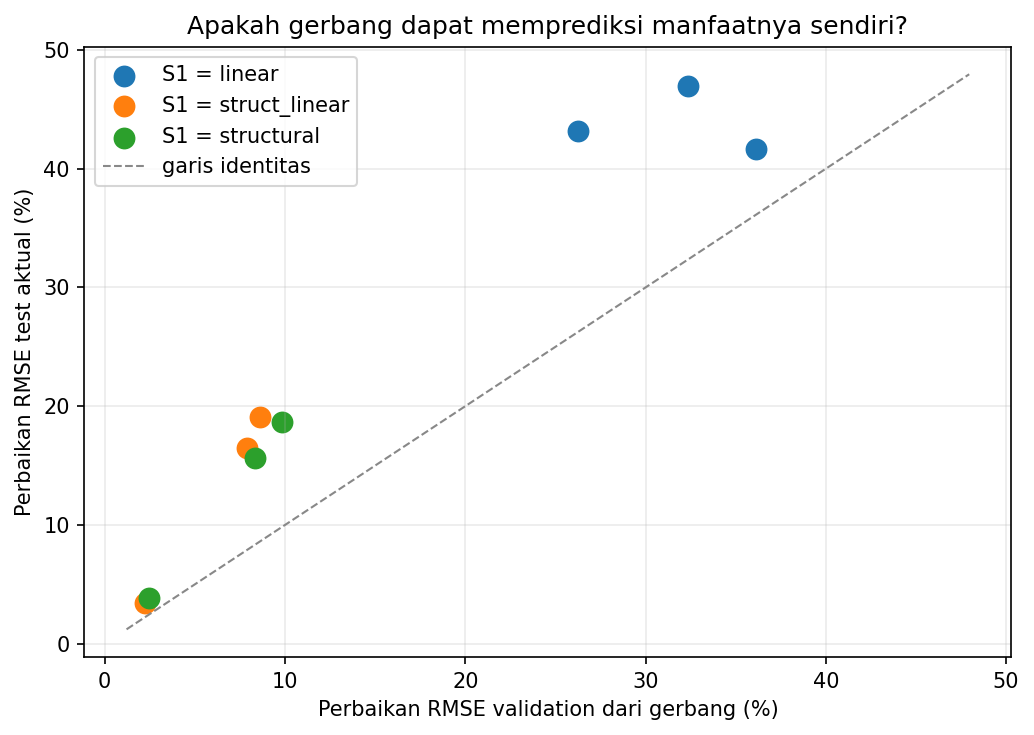

In [7]:
diag = results[results.model.str.startswith("AR-LRX")][
    ["feature_set", "stage1", "gate_w", "stage1_val_RMSE", "gate_val_gain_pct",
     "resid_val_r2", "stage1_only_test_RMSE", "test_RMSE"]].copy()
diag["perbaikan test aktual (%)"] = (
    (diag["stage1_only_test_RMSE"] - diag["test_RMSE"]) / diag["stage1_only_test_RMSE"] * 100)
display(diag.round(4).to_string(index=False))

if len(diag) > 2:
    rho = diag[["gate_val_gain_pct", "perbaikan test aktual (%)"]].corr().iloc[0, 1]
    print(f"\nKorelasi perbaikan validation vs perbaikan test aktual: r = {rho:.3f}")
    print("Korelasi tinggi berarti gerbang dapat dipakai sebagai kriteria keputusan"
          " tanpa melihat test.")

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
for kind, g in diag.groupby("stage1"):
    ax.scatter(g["gate_val_gain_pct"], g["perbaikan test aktual (%)"],
               s=90, label=f"S1 = {kind}")
lim = [min(diag["gate_val_gain_pct"].min(), diag["perbaikan test aktual (%)"].min()) - 1,
       max(diag["gate_val_gain_pct"].max(), diag["perbaikan test aktual (%)"].max()) + 1]
ax.plot(lim, lim, "--", lw=1, color="#888", label="garis identitas")
ax.set_xlabel("Perbaikan RMSE validation dari gerbang (%)")
ax.set_ylabel("Perbaikan RMSE test aktual (%)")
ax.set_title("Apakah gerbang dapat memprediksi manfaatnya sendiri?")
ax.legend(); ax.grid(alpha=.25); plt.tight_layout(); plt.show()

## 6. Sumbangan tiap komponen (ablasi)

Tabel ini memisahkan tiga sumber perbaikan sehingga naskah dapat menyatakan
berapa persen berasal dari tahap pertama yang lebih baik, dan berapa dari gerbang.

In [8]:
abl = []
for variant in VARIANTS:
    sub = results[results.feature_set == variant].set_index("model")
    old = sub.loc["LR-XGB (residual, tanpa gerbang)", "orig_RMSE"]
    abl.append({
        "varian": variant,
        "kerangka lama (S1=linear, tanpa gerbang)": old,
        "+ gerbang saja (S1=linear)": sub.loc["AR-LRX [linear]", "orig_RMSE"],
        "+ S1 struktural saja (tanpa koreksi)": sub.loc["S1 [structural]", "orig_RMSE"],
        "AR-LRX penuh (S1=struct_linear + gerbang)": sub.loc["AR-LRX [struct_linear]", "orig_RMSE"],
    })
abl = pd.DataFrame(abl).set_index("varian")
abl["total perbaikan (%)"] = ((abl.iloc[:, 0] - abl.iloc[:, 3]) / abl.iloc[:, 0] * 100)
abl.to_csv(f"../results/{EXPERIMENT}_ablation.csv")
display(abl.round(3))

,"kerangka lama (S1=linear, tanpa gerbang)",+ gerbang saja (S1=linear),+ S1 struktural saja (tanpa koreksi),AR-LRX penuh (S1=struct_linear + gerbang),total perbaikan (%)
varian,,,,,
V1_customers_dropped,1651.054,1689.390,1240.636,1199.832,27.329
V2_customers_lagged,1153.285,1196.442,1240.636,1045.866,9.314
V3_sales_lagged,1061.497,1140.799,1240.636,998.149,5.968


## 7. Pemeriksaan determinisme

In [9]:
P.set_global_seed()
d = datasets["V1_customers_dropped"]
again = A.run_arlrx("AR-LRX [struct_linear]", d, "struct_linear", XGB_GRID,
                    inverse_transform=np.expm1)
first = by_key[("V1_customers_dropped", "AR-LRX [struct_linear]")]
print("Prediksi identik bit-per-bit:",
      np.array_equal(again["_test_pred"], first["_test_pred"]))
print(f"RMSE (log): {again['test_RMSE']:.8f} vs {first['test_RMSE']:.8f}")
print("Hyperparameter identik:", again["params"] == first["params"],
      "| gerbang identik:", again["gate_w"] == first["gate_w"])

Prediksi identik bit-per-bit: True
RMSE (log): 0.15423512 vs 0.15423512
Hyperparameter identik: True | gerbang identik: True


## 8. Cara melaporkan di naskah dan disertasi

* **Kerangka lama adalah kasus khusus AR-LRX** (`S1 = linear`, `w = 1`). Nyatakan itu
  secara eksplisit: perbandingannya karena itu bukan antar-protokol, melainkan antar
  konfigurasi dari satu kerangka yang sama. Ini menutup kritik reviewer nomor 1
  secara struktural, bukan sekadar dengan menyamakan split.
* **Klaim yang dapat dipertahankan** bukan "model kami paling akurat", melainkan:
  (a) kualitas tahap pertama menentukan apakah koreksi residual berguna - terukur
  sebagai selisih antara `S1 [linear]` dan `S1 [struct_linear]`; (b) gerbang membuat
  kerangka aman ketika residual tidak dapat diprediksi; (c) nilai gerbang yang dipilih
  di validation dapat dipakai sebagai kriteria keputusan sebelum menyentuh test.
* **Jangan menyembunyikan varian yang kalah.** Bila AR-LRX tetap kalah dari XGBoost
  polos pada suatu varian, laporkan dan jelaskan lewat diagnostik bagian 5. Justru
  kombinasi "menang di sini, kalah di sana, dan inilah kriteria yang membedakannya"
  yang membuat kontribusinya bersifat metodologis, bukan sekadar empiris.
* Angka lama Rossmann (RMSE 577,63) tetap tidak boleh dipakai: ia berasal dari `V0`.